In [1]:
import warnings
warnings.filterwarnings("ignore")

## Imports e Diretório

In [2]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [3]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Base Funil

In [21]:
cp_funil_df = pd.read_parquet(ANALYTICS_DIR/"query_credpago_funil_df.parquet")
cp_funil_df["safra"] = pd.to_datetime(cp_funil_df["requested_at"]).dt.strftime("%Y-%m")
cp_funil_df = cp_funil_df[(cp_funil_df["safra"] >= "2026-01")&(cp_funil_df["is_fallback"] == 0)]
cp_funil_df

,contract_id,dt_lead,requested_at,iniciada_at,enviada_at,activated_at,cancelled_at,dt_saida,tipo_contrato,product_nm,...,is_activeted,CPF_CNPJ,data_consulta,model,pessoas_scores_BVS_CUSTOM,pessoas_scores_BVS_CUSTOM_V2,pessoas_scores_HVA4,pessoas_scores_HFT1,pessoas_rendaConsideradaPessoa,safra
114,3794945,2026-02-20,2026-02-20,NaT,NaT,NaT,NaT,NaT,PF,None,...,False,92380140510,2026-02-20,BLEND_REGRESSAO_2026,600.0,NaN,NaN,NaN,4178.5,2026-02
115,3794057,2026-02-20,2026-02-20,NaT,NaT,NaT,NaT,NaT,PF,None,...,False,45560951072,2026-02-20,BLEND_REGRESSAO,720.0,NaN,NaN,NaN,7398.0,2026-02
116,3792412,2026-02-20,2026-02-20,NaT,NaT,NaT,NaT,NaT,PF,None,...,False,55559166987,2026-02-20,BLEND_REGRESSAO_2026,661.0,NaN,NaN,NaN,2397.5,2026-02
117,3790283,2026-02-20,2026-02-20,NaT,NaT,NaT,2026-02-20,NaT,PF,None,...,False,12270108850,2026-02-20,BLEND_REGRESSAO_2026,430.0,NaN,NaN,NaN,3288.0,2026-02
118,3794572,2026-02-20,2026-02-20,NaT,NaT,NaT,2026-02-20,NaT,PF,None,...,False,48271549880,2026-02-20,BLEND_REGRESSAO,501.0,NaN,NaN,NaN,1096.0,2026-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2199905,3828775,2026-02-28,2026-02-28,NaT,NaT,NaT,2026-07-08,NaT,PF,None,...,False,71229956239,2026-02-28,BLEND_REGRESSAO,497.0,NaN,NaN,NaN,2192.0,2026-02
2199906,3828915,2026-02-28,2026-02-28,NaT,NaT,NaT,2026-07-08,NaT,PF,None,...,False,16325883748,2026-02-28,BLEND_REGRESSAO_2026,706.0,NaN,NaN,NaN,2055.0,2026-02
2199907,3829061,2026-02-28,2026-02-28,2026-02-28,NaT,NaT,2026-06-20,NaT,PF,Smart Plus,...,False,1716035244,2026-02-28,BLEND_REGRESSAO,660.0,NaN,NaN,NaN,8494.0,2026-02
2199908,3829652,2026-02-28,2026-02-28,2026-02-28,2026-02-28,2026-03-12,NaT,NaT,PF,Fit,...,True,6376936989,2026-02-28,BLEND_REGRESSAO,872.0,NaN,NaN,NaN,17878.5,2026-02


In [5]:
cp_funil_df.columns

Index(['contract_id', 'dt_lead', 'requested_at', 'iniciada_at', 'enviada_at',
       'activated_at', 'cancelled_at', 'dt_saida', 'tipo_contrato',
       'product_nm', 'modeloBlend', 'bureau_nm', 'modelo_blend',
       'bureau_nm_ajust', 'is_fallback', 'total_rental_value_informed_nr',
       'rental_value_nr', 'qtd_proponentes', 'score_imobiliaria',
       'person_restriction_total_value', 'bvs_cust_score_nr',
       'blend_regressao_predict_nr', 'rating_score_ds', 'pre_analysis_result',
       'lead_elegivel', 'proposta_iniciada', 'proposta_enviada',
       'proposta_aprovada', 'proposta_ativada', 'is_activeted', 'CPF_CNPJ',
       'data_consulta', 'model', 'pessoas_scores_BVS_CUSTOM',
       'pessoas_scores_BVS_CUSTOM_V2', 'pessoas_scores_HVA4',
       'pessoas_scores_HFT1', 'pessoas_rendaConsideradaPessoa'],
      dtype='object')

In [27]:
cp_funil_df.groupby("bureau_nm", dropna=False).size()

bureau_nm
                           117
BLEND3_2                 40001
BLEND3_3                344942
BLEND_4                   8211
BLEND_REGRESSAO         168961
BLEND_REGRESSAO_2026    117050
HVA3                     35573
NaN                         64
dtype: int64

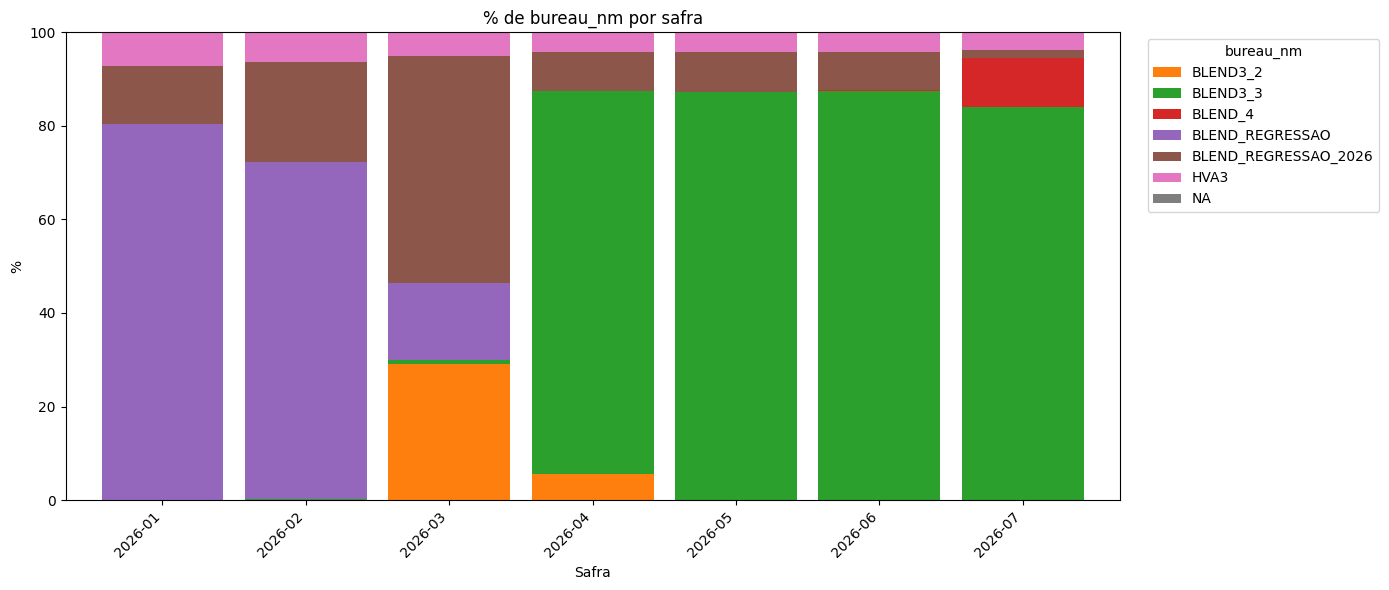

In [23]:
# 3) % de bureau_nm_ajust por safra (stacked bar)
plot_df = cp_funil_df.copy()
plot_df["bureau_nm"] = plot_df["bureau_nm"].fillna("NA")

safra_order = sorted(plot_df["safra"].dropna().unique())

pct_df = (
    pd.crosstab(plot_df["safra"], plot_df["bureau_nm"], normalize="index")
    .mul(100)
    .reindex(index=safra_order)
)

ax = pct_df.plot(kind="bar", stacked=True, figsize=(14, 6), width=0.85)

ax.set_title("% de bureau_nm por safra")
ax.set_xlabel("Safra")
ax.set_ylabel("%")
ax.set_ylim(0, 100)
ax.legend(title="bureau_nm", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [29]:
from IPython.display import display
from funcoes_monitoramento import (
    prepare_blend_funnel_columns,
    prepare_week_columns,
    build_blend_rating_decision_tables,
    display_blend_rating_decision_tables,
)

MODEL_COL = "bureau_nm"
RATING_COL = "rating_score_ds"
RATING_ORDER = ["A", "B", "C", "D", "E", "N/I"]  # valide com value_counts
PRE_ANALISE_ORDER = ["APROVAR", "DERIVAR", "REPROVAR"]

MODELS_4 = [
    "BLEND_REGRESSAO",
    "BLEND_REGRESSAO_2026",
    "BLEND3_2",
    "BLEND3_3",
]
MODELS_2 = ["BLEND2", "BLEND3"]

MODEL_COLOR_MAP = {
    "BLEND_REGRESSAO": "#94A3B8",
    "BLEND_REGRESSAO_2026": "#64748B",
    "BLEND3_2": "#60A5FA",
    "BLEND3_3": "#2563EB",
    "BLEND2": "#94A3B8",
    "BLEND3": "#2563EB",
}

BLEND2_SET = {"BLEND_REGRESSAO", "BLEND_REGRESSAO_2026"}
BLEND3_SET = {"BLEND3_2", "BLEND3_3"}
SAFRAS = ["2026-03", "2026-04", "2026-05"]  # janela da troca; remova se quiser tudo

# --- base ---
df = cp_funil_df.copy()
df["requested_at"] = pd.to_datetime(df["requested_at"])
df["safra"] = df["requested_at"].dt.strftime("%Y-%m")
df = df[df["safra"].isin(SAFRAS)].copy()
df = df[df[MODEL_COL].isin(MODELS_4)].copy()

df["model_group"] = np.where(
    df[MODEL_COL].isin(BLEND2_SET), "BLEND2",
    np.where(df[MODEL_COL].isin(BLEND3_SET), "BLEND3", None),
)

df = prepare_blend_funnel_columns(df)
df = prepare_week_columns(df, "requested_at")

weeks = sorted(df["year_week"].dropna().unique().tolist())
print("Semanas:", weeks)
display(df[RATING_COL].value_counts(dropna=False))

Semanas: ['2026-03-01', '2026-03-08', '2026-03-15', '2026-03-22', '2026-03-29', '2026-04-05', '2026-04-12', '2026-04-19', '2026-04-26', '2026-05-03', '2026-05-10', '2026-05-17', '2026-05-24', '2026-05-31']


rating_score_ds
E      129613
C       75840
B       58403
A       36909
D       15535
N/I       399
Name: count, dtype: int64

In [30]:
for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df,
        models=MODELS_4,
        model_col=MODEL_COL,
        rating_col=RATING_COL,
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )
    display_blend_rating_decision_tables(
        counts, rates, week_label=week_label, title_prefix="4 modelos"
    )

### 4 modelos — Semana 2026-03-01

**Leads (Counts)**

**Ativado / Lead (%)**

### 4 modelos — Semana 2026-03-08

**Leads (Counts)**

...

**Leads (Counts)**

**Ativado / Lead (%)**

### 4 modelos — Semana 2026-05-31

**Leads (Counts)**

**Ativado / Lead (%)**

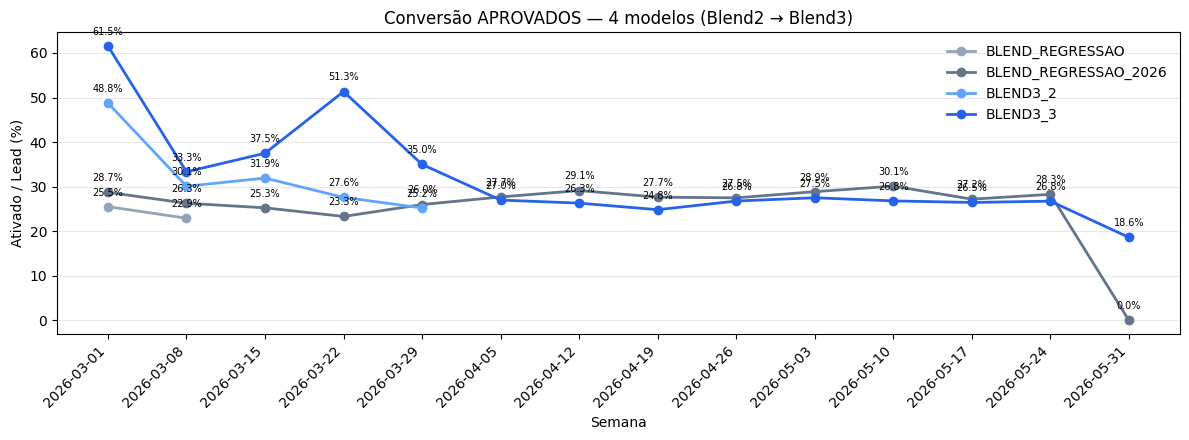

In [31]:
rows = []
for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df,
        models=MODELS_4,
        model_col=MODEL_COL,
        rating_col=RATING_COL,
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )
    for model in MODELS_4:
        leads = counts.loc["Total", (model, "APROVADO")]
        pct = np.nan if (leads == 0 or pd.isna(leads)) else rates.loc["Total", (model, "APROVADO")]
        rows.append({"week": week_label, "model": model, "ativados_pct": pct})

pivot = (
    pd.DataFrame(rows)
    .pivot(index="week", columns="model", values="ativados_pct")
    .reindex(columns=MODELS_4)
)

fig, ax = plt.subplots(figsize=(12, 4.5))
x = range(len(pivot.index))
for model in MODELS_4:
    ax.plot(
        x, pivot[model], marker="o", linewidth=2,
        label=model, color=MODEL_COLOR_MAP.get(model),
    )
    for i, v in enumerate(pivot[model]):
        if pd.notna(v):
            ax.annotate(
                f"{v:.1f}%", (i, v),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=7,
            )

ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index, rotation=45, ha="right")
ax.set_ylabel("Ativado / Lead (%)")
ax.set_xlabel("Semana")
ax.set_title("Conversão APROVADOS — 4 modelos (Blend2 → Blend3)")
ax.legend(frameon=False, loc="best")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

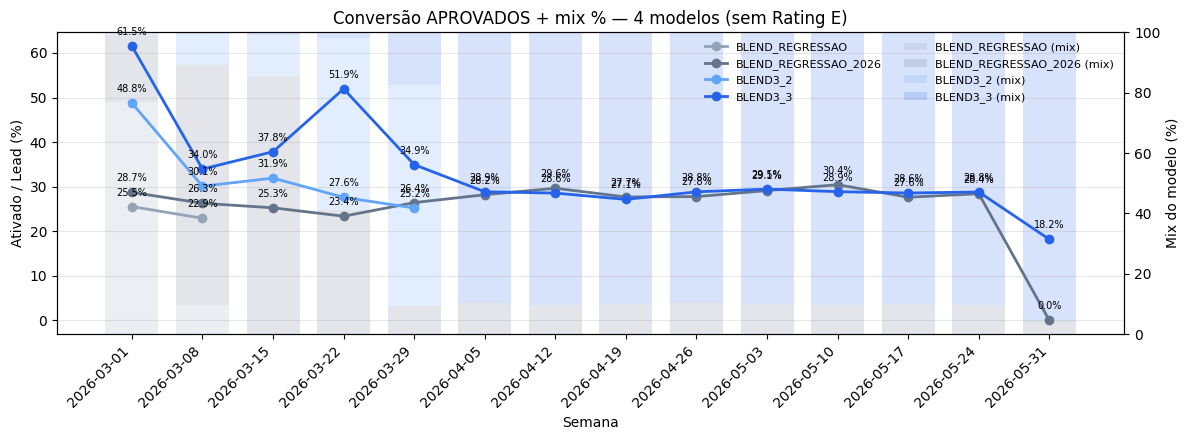

In [39]:
rows_conv = []
rows_mix = []

for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df,
        models=MODELS_4,
        model_col=MODEL_COL,
        rating_col=RATING_COL,
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )

    # volume total do modelo na semana (soma das decisões)
    leads_by_model = {
        model: counts.loc["Total", (model, slice(None))].sum()
        for model in MODELS_4
    }
    total_leads = sum(leads_by_model.values())

    for model in MODELS_4:
        leads_aprov = counts.loc["Total", (model, "APROVADO")]
        pct_conv = (
            np.nan
            if (leads_aprov == 0 or pd.isna(leads_aprov))
            else rates.loc["Total", (model, "APROVADO")]
        )
        rows_conv.append({"week": week_label, "model": model, "ativados_pct": pct_conv})

        mix = np.nan if total_leads == 0 else 100 * leads_by_model[model] / total_leads
        rows_mix.append({"week": week_label, "model": model, "mix_pct": mix})

pivot_conv = (
    pd.DataFrame(rows_conv)
    .pivot(index="week", columns="model", values="ativados_pct")
    .reindex(columns=MODELS_4)
)
pivot_mix = (
    pd.DataFrame(rows_mix)
    .pivot(index="week", columns="model", values="mix_pct")
    .reindex(columns=MODELS_4)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(pivot_conv.index))
width = 0.75

# --- fundo: mix % (barras empilhadas) ---
ax_bg = ax.twinx()
bottom = np.zeros(len(x))
for model in MODELS_4:
    vals = pivot_mix[model].to_numpy()
    ax_bg.bar(
        x, vals, width=width, bottom=bottom,
        color=MODEL_COLOR_MAP.get(model),
        alpha=0.18, edgecolor="none", zorder=1,
        label=f"{model} (mix)",
    )
    bottom += vals

ax_bg.set_ylabel("Mix do modelo (%)")
ax_bg.set_ylim(0, 100)
ax_bg.set_zorder(1)

# --- frente: conversão APROVADOS ---
ax.set_zorder(2)
ax.patch.set_visible(False)

for model in MODELS_4:
    ax.plot(
        x, pivot_conv[model], marker="o", linewidth=2,
        label=model, color=MODEL_COLOR_MAP.get(model), zorder=3,
    )
    for i, v in enumerate(pivot_conv[model]):
        if pd.notna(v):
            ax.annotate(
                f"{v:.1f}%", (i, v),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=7, zorder=4,
            )

ax.set_xticks(list(x))
ax.set_xticklabels(pivot_conv.index, rotation=45, ha="right")
ax.set_ylabel("Ativado / Lead (%)")
ax.set_xlabel("Semana")
ax.set_title("Conversão APROVADOS + mix % — 4 modelos (sem Rating E)")
ax.grid(axis="y", alpha=0.3, zorder=0)

# legenda: linhas (conversão) + barras (mix)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_bg.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, loc="best", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

In [32]:
for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df,
        models=MODELS_2,
        model_col="model_group",
        rating_col=RATING_COL,
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )
    display_blend_rating_decision_tables(
        counts, rates, week_label=week_label, title_prefix="Blend2 vs Blend3"
    )

### Blend2 vs Blend3 — Semana 2026-03-01

**Leads (Counts)**

**Ativado / Lead (%)**

### Blend2 vs Blend3 — Semana 2026-03-08

**Leads (Counts)**

...

**Leads (Counts)**

**Ativado / Lead (%)**

### Blend2 vs Blend3 — Semana 2026-05-31

**Leads (Counts)**

**Ativado / Lead (%)**

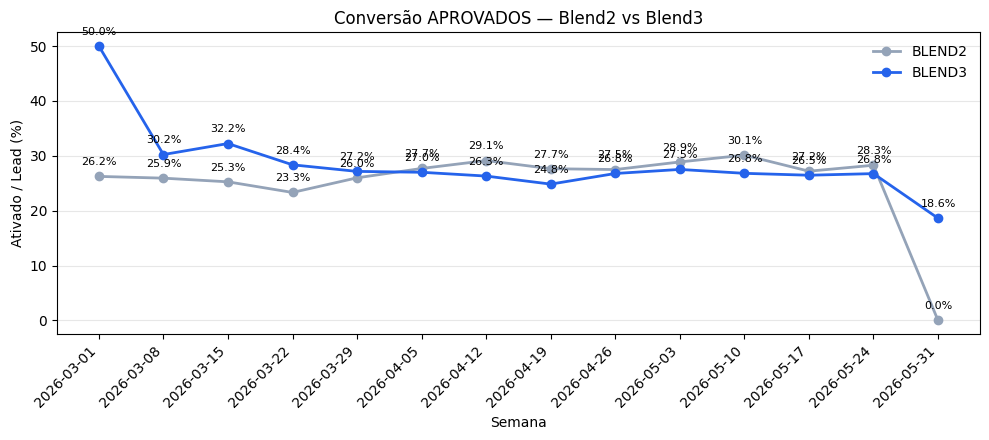

In [33]:
rows = []
for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df,
        models=MODELS_2,
        model_col="model_group",
        rating_col=RATING_COL,
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )
    for model in MODELS_2:
        leads = counts.loc["Total", (model, "APROVADO")]
        pct = np.nan if (leads == 0 or pd.isna(leads)) else rates.loc["Total", (model, "APROVADO")]
        rows.append({"week": week_label, "model": model, "ativados_pct": pct})

pivot = (
    pd.DataFrame(rows)
    .pivot(index="week", columns="model", values="ativados_pct")
    .reindex(columns=MODELS_2)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = range(len(pivot.index))
for model in MODELS_2:
    ax.plot(
        x, pivot[model], marker="o", linewidth=2,
        label=model, color=MODEL_COLOR_MAP.get(model),
    )
    for i, v in enumerate(pivot[model]):
        if pd.notna(v):
            ax.annotate(
                f"{v:.1f}%", (i, v),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8,
            )

ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index, rotation=45, ha="right")
ax.set_ylabel("Ativado / Lead (%)")
ax.set_xlabel("Semana")
ax.set_title("Conversão APROVADOS — Blend2 vs Blend3")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

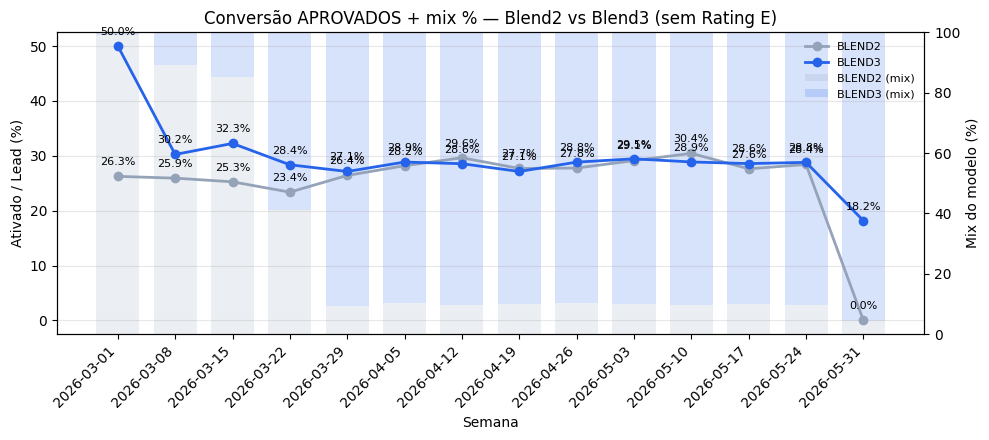

In [40]:
rows_conv = []
rows_mix = []

for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df,
        models=MODELS_2,
        model_col="model_group",
        rating_col=RATING_COL,
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )

    leads_by_model = {
        model: counts.loc["Total", (model, slice(None))].sum()
        for model in MODELS_2
    }
    total_leads = sum(leads_by_model.values())

    for model in MODELS_2:
        leads_aprov = counts.loc["Total", (model, "APROVADO")]
        pct_conv = (
            np.nan
            if (leads_aprov == 0 or pd.isna(leads_aprov))
            else rates.loc["Total", (model, "APROVADO")]
        )
        rows_conv.append({"week": week_label, "model": model, "ativados_pct": pct_conv})

        mix = np.nan if total_leads == 0 else 100 * leads_by_model[model] / total_leads
        rows_mix.append({"week": week_label, "model": model, "mix_pct": mix})

pivot_conv = (
    pd.DataFrame(rows_conv)
    .pivot(index="week", columns="model", values="ativados_pct")
    .reindex(columns=MODELS_2)
)
pivot_mix = (
    pd.DataFrame(rows_mix)
    .pivot(index="week", columns="model", values="mix_pct")
    .reindex(columns=MODELS_2)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(pivot_conv.index))
width = 0.75

# fundo: mix %
ax_bg = ax.twinx()
bottom = np.zeros(len(x))
for model in MODELS_2:
    vals = pivot_mix[model].to_numpy()
    ax_bg.bar(
        x, vals, width=width, bottom=bottom,
        color=MODEL_COLOR_MAP.get(model),
        alpha=0.18, edgecolor="none", zorder=1,
        label=f"{model} (mix)",
    )
    bottom += vals

ax_bg.set_ylabel("Mix do modelo (%)")
ax_bg.set_ylim(0, 100)
ax_bg.set_zorder(1)

# frente: conversão
ax.set_zorder(2)
ax.patch.set_visible(False)

for model in MODELS_2:
    ax.plot(
        x, pivot_conv[model], marker="o", linewidth=2,
        label=model, color=MODEL_COLOR_MAP.get(model), zorder=3,
    )
    for i, v in enumerate(pivot_conv[model]):
        if pd.notna(v):
            ax.annotate(
                f"{v:.1f}%", (i, v),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8, zorder=4,
            )

ax.set_xticks(list(x))
ax.set_xticklabels(pivot_conv.index, rotation=45, ha="right")
ax.set_ylabel("Ativado / Lead (%)")
ax.set_xlabel("Semana")
ax.set_title("Conversão APROVADOS + mix % — Blend2 vs Blend3 (sem Rating E)")
ax.grid(axis="y", alpha=0.3, zorder=0)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_bg.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, loc="best", fontsize=8)

plt.tight_layout()
plt.show()

## Sem Rating E

In [34]:
from IPython.display import display
from funcoes_monitoramento import (
    prepare_blend_funnel_columns,
    prepare_week_columns,
    build_blend_rating_decision_tables,
    display_blend_rating_decision_tables,
)

MODEL_COL = "bureau_nm"
RATING_COL = "rating_score_ds"
RATING_ORDER = ["A", "B", "C", "D"]  # sem E
PRE_ANALISE_ORDER = ["APROVAR", "DERIVAR", "REPROVAR"]

MODELS_4 = [
    "BLEND_REGRESSAO",
    "BLEND_REGRESSAO_2026",
    "BLEND3_2",
    "BLEND3_3",
]
MODELS_2 = ["BLEND2", "BLEND3"]

MODEL_COLOR_MAP = {
    "BLEND_REGRESSAO": "#94A3B8",
    "BLEND_REGRESSAO_2026": "#64748B",
    "BLEND3_2": "#60A5FA",
    "BLEND3_3": "#2563EB",
    "BLEND2": "#94A3B8",
    "BLEND3": "#2563EB",
}

BLEND2_SET = {"BLEND_REGRESSAO", "BLEND_REGRESSAO_2026"}
BLEND3_SET = {"BLEND3_2", "BLEND3_3"}
SAFRAS = ["2026-03", "2026-04", "2026-05"]

df = cp_funil_df.copy()
df["requested_at"] = pd.to_datetime(df["requested_at"])
df["safra"] = df["requested_at"].dt.strftime("%Y-%m")
df = df[df["safra"].isin(SAFRAS)].copy()
df = df[df[MODEL_COL].isin(MODELS_4)].copy()
df = df[df[RATING_COL].isin(RATING_ORDER)].copy()  # remove E (e qualquer outro fora da lista)

df["model_group"] = df[MODEL_COL].map(
    {
        "BLEND_REGRESSAO": "BLEND2",
        "BLEND_REGRESSAO_2026": "BLEND2",
        "BLEND3_2": "BLEND3",
        "BLEND3_3": "BLEND3",
    }
)

df = prepare_blend_funnel_columns(df)
df = prepare_week_columns(df, "requested_at")

weeks = sorted(df["year_week"].dropna().unique().tolist())
print("Semanas:", weeks)
display(df[RATING_COL].value_counts(dropna=False))

Semanas: ['2026-03-01', '2026-03-08', '2026-03-15', '2026-03-22', '2026-03-29', '2026-04-05', '2026-04-12', '2026-04-19', '2026-04-26', '2026-05-03', '2026-05-10', '2026-05-17', '2026-05-24', '2026-05-31']


rating_score_ds
C    75840
B    58403
A    36909
D    15535
Name: count, dtype: int64

In [35]:
for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df,
        models=MODELS_4,
        model_col=MODEL_COL,
        rating_col=RATING_COL,
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )
    display_blend_rating_decision_tables(
        counts, rates, week_label=week_label, title_prefix="4 modelos (sem E)"
    )

### 4 modelos (sem E) — Semana 2026-03-01

**Leads (Counts)**

**Ativado / Lead (%)**

### 4 modelos (sem E) — Semana 2026-03-08

**Leads (Counts)**

...

**Leads (Counts)**

**Ativado / Lead (%)**

### 4 modelos (sem E) — Semana 2026-05-31

**Leads (Counts)**

**Ativado / Lead (%)**

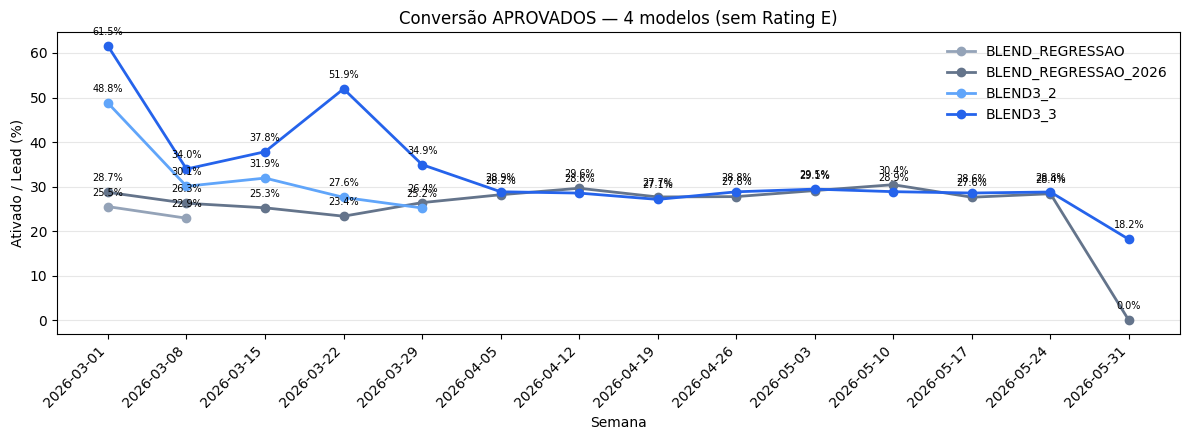

In [36]:
rows = []
for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df,
        models=MODELS_4,
        model_col=MODEL_COL,
        rating_col=RATING_COL,
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )
    for model in MODELS_4:
        leads = counts.loc["Total", (model, "APROVADO")]
        pct = np.nan if (leads == 0 or pd.isna(leads)) else rates.loc["Total", (model, "APROVADO")]
        rows.append({"week": week_label, "model": model, "ativados_pct": pct})

pivot = (
    pd.DataFrame(rows)
    .pivot(index="week", columns="model", values="ativados_pct")
    .reindex(columns=MODELS_4)
)

fig, ax = plt.subplots(figsize=(12, 4.5))
x = range(len(pivot.index))
for model in MODELS_4:
    ax.plot(
        x, pivot[model], marker="o", linewidth=2,
        label=model, color=MODEL_COLOR_MAP.get(model),
    )
    for i, v in enumerate(pivot[model]):
        if pd.notna(v):
            ax.annotate(
                f"{v:.1f}%", (i, v),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=7,
            )

ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index, rotation=45, ha="right")
ax.set_ylabel("Ativado / Lead (%)")
ax.set_xlabel("Semana")
ax.set_title("Conversão APROVADOS — 4 modelos (sem Rating E)")
ax.legend(frameon=False, loc="best")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

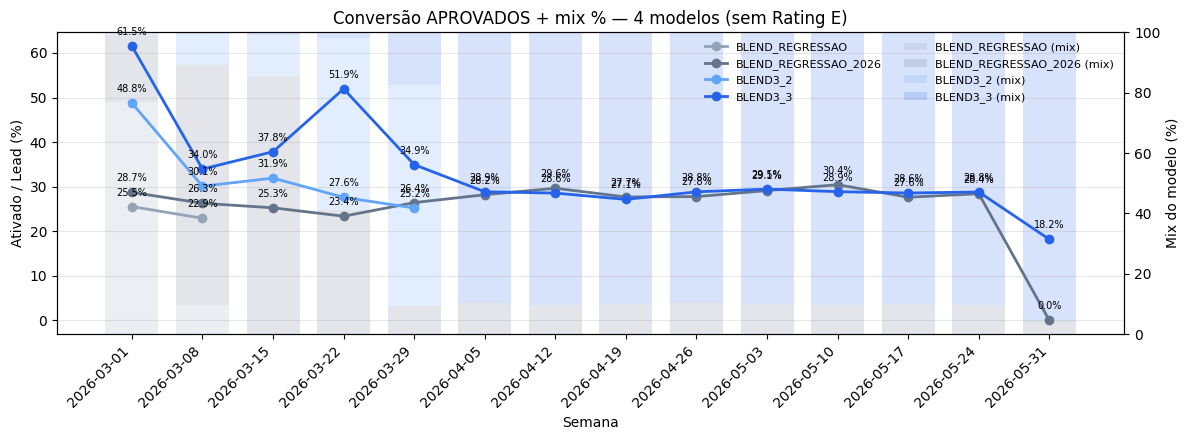

In [41]:
rows_conv = []
rows_mix = []

for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df,
        models=MODELS_4,
        model_col=MODEL_COL,
        rating_col=RATING_COL,
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )

    leads_by_model = {
        model: counts.loc["Total", (model, slice(None))].sum()
        for model in MODELS_4
    }
    total_leads = sum(leads_by_model.values())

    for model in MODELS_4:
        leads_aprov = counts.loc["Total", (model, "APROVADO")]
        pct_conv = (
            np.nan
            if (leads_aprov == 0 or pd.isna(leads_aprov))
            else rates.loc["Total", (model, "APROVADO")]
        )
        rows_conv.append({"week": week_label, "model": model, "ativados_pct": pct_conv})

        mix = np.nan if total_leads == 0 else 100 * leads_by_model[model] / total_leads
        rows_mix.append({"week": week_label, "model": model, "mix_pct": mix})

pivot_conv = (
    pd.DataFrame(rows_conv)
    .pivot(index="week", columns="model", values="ativados_pct")
    .reindex(columns=MODELS_4)
)
pivot_mix = (
    pd.DataFrame(rows_mix)
    .pivot(index="week", columns="model", values="mix_pct")
    .reindex(columns=MODELS_4)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(pivot_conv.index))
width = 0.75

# fundo: mix %
ax_bg = ax.twinx()
bottom = np.zeros(len(x))
for model in MODELS_4:
    vals = pivot_mix[model].to_numpy()
    ax_bg.bar(
        x, vals, width=width, bottom=bottom,
        color=MODEL_COLOR_MAP.get(model),
        alpha=0.18, edgecolor="none", zorder=1,
        label=f"{model} (mix)",
    )
    bottom += vals

ax_bg.set_ylabel("Mix do modelo (%)")
ax_bg.set_ylim(0, 100)
ax_bg.set_zorder(1)

# frente: conversão
ax.set_zorder(2)
ax.patch.set_visible(False)

for model in MODELS_4:
    ax.plot(
        x, pivot_conv[model], marker="o", linewidth=2,
        label=model, color=MODEL_COLOR_MAP.get(model), zorder=3,
    )
    for i, v in enumerate(pivot_conv[model]):
        if pd.notna(v):
            ax.annotate(
                f"{v:.1f}%", (i, v),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=7, zorder=4,
            )

ax.set_xticks(list(x))
ax.set_xticklabels(pivot_conv.index, rotation=45, ha="right")
ax.set_ylabel("Ativado / Lead (%)")
ax.set_xlabel("Semana")
ax.set_title("Conversão APROVADOS + mix % — 4 modelos (sem Rating E)")
ax.grid(axis="y", alpha=0.3, zorder=0)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_bg.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, loc="best", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

In [37]:
for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df,
        models=MODELS_2,
        model_col="model_group",
        rating_col=RATING_COL,
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )
    display_blend_rating_decision_tables(
        counts, rates, week_label=week_label, title_prefix="Blend2 vs Blend3 (sem E)"
    )

### Blend2 vs Blend3 (sem E) — Semana 2026-03-01

**Leads (Counts)**

**Ativado / Lead (%)**

### Blend2 vs Blend3 (sem E) — Semana 2026-03-08

**Leads (Counts)**

...

**Leads (Counts)**

**Ativado / Lead (%)**

### Blend2 vs Blend3 (sem E) — Semana 2026-05-31

**Leads (Counts)**

**Ativado / Lead (%)**

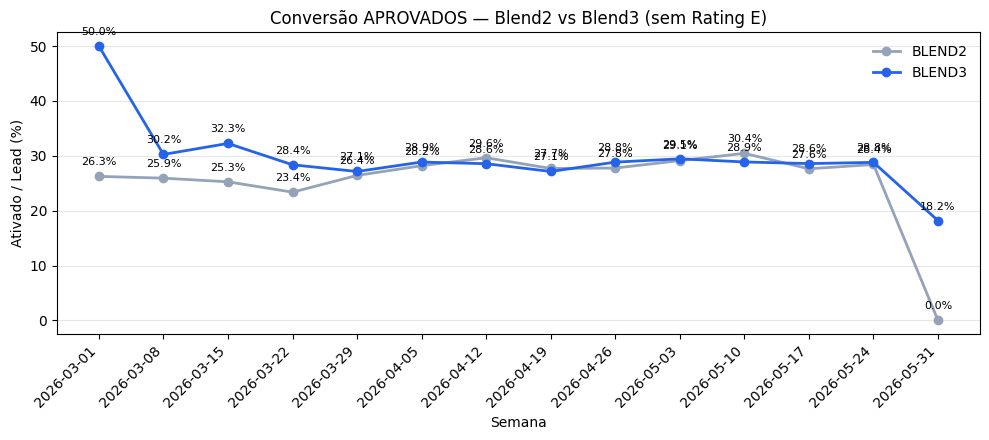

In [38]:
rows = []
for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df,
        models=MODELS_2,
        model_col="model_group",
        rating_col=RATING_COL,
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )
    for model in MODELS_2:
        leads = counts.loc["Total", (model, "APROVADO")]
        pct = np.nan if (leads == 0 or pd.isna(leads)) else rates.loc["Total", (model, "APROVADO")]
        rows.append({"week": week_label, "model": model, "ativados_pct": pct})

pivot = (
    pd.DataFrame(rows)
    .pivot(index="week", columns="model", values="ativados_pct")
    .reindex(columns=MODELS_2)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = range(len(pivot.index))
for model in MODELS_2:
    ax.plot(
        x, pivot[model], marker="o", linewidth=2,
        label=model, color=MODEL_COLOR_MAP.get(model),
    )
    for i, v in enumerate(pivot[model]):
        if pd.notna(v):
            ax.annotate(
                f"{v:.1f}%", (i, v),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8,
            )

ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index, rotation=45, ha="right")
ax.set_ylabel("Ativado / Lead (%)")
ax.set_xlabel("Semana")
ax.set_title("Conversão APROVADOS — Blend2 vs Blend3 (sem Rating E)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

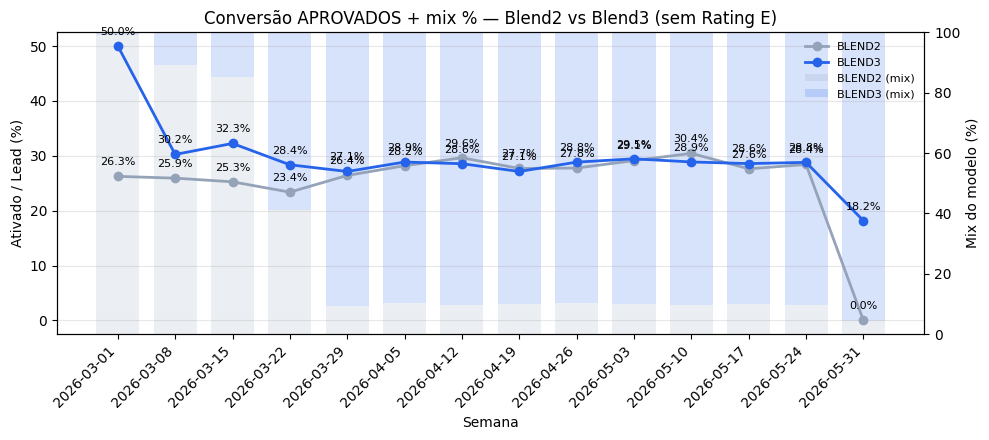

In [42]:
rows_conv = []
rows_mix = []

for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df,
        models=MODELS_2,
        model_col="model_group",
        rating_col=RATING_COL,
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )

    leads_by_model = {
        model: counts.loc["Total", (model, slice(None))].sum()
        for model in MODELS_2
    }
    total_leads = sum(leads_by_model.values())

    for model in MODELS_2:
        leads_aprov = counts.loc["Total", (model, "APROVADO")]
        pct_conv = (
            np.nan
            if (leads_aprov == 0 or pd.isna(leads_aprov))
            else rates.loc["Total", (model, "APROVADO")]
        )
        rows_conv.append({"week": week_label, "model": model, "ativados_pct": pct_conv})

        mix = np.nan if total_leads == 0 else 100 * leads_by_model[model] / total_leads
        rows_mix.append({"week": week_label, "model": model, "mix_pct": mix})

pivot_conv = (
    pd.DataFrame(rows_conv)
    .pivot(index="week", columns="model", values="ativados_pct")
    .reindex(columns=MODELS_2)
)
pivot_mix = (
    pd.DataFrame(rows_mix)
    .pivot(index="week", columns="model", values="mix_pct")
    .reindex(columns=MODELS_2)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(pivot_conv.index))
width = 0.75

ax_bg = ax.twinx()
bottom = np.zeros(len(x))
for model in MODELS_2:
    vals = pivot_mix[model].to_numpy()
    ax_bg.bar(
        x, vals, width=width, bottom=bottom,
        color=MODEL_COLOR_MAP.get(model),
        alpha=0.18, edgecolor="none", zorder=1,
        label=f"{model} (mix)",
    )
    bottom += vals

ax_bg.set_ylabel("Mix do modelo (%)")
ax_bg.set_ylim(0, 100)
ax_bg.set_zorder(1)

ax.set_zorder(2)
ax.patch.set_visible(False)

for model in MODELS_2:
    ax.plot(
        x, pivot_conv[model], marker="o", linewidth=2,
        label=model, color=MODEL_COLOR_MAP.get(model), zorder=3,
    )
    for i, v in enumerate(pivot_conv[model]):
        if pd.notna(v):
            ax.annotate(
                f"{v:.1f}%", (i, v),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8, zorder=4,
            )

ax.set_xticks(list(x))
ax.set_xticklabels(pivot_conv.index, rotation=45, ha="right")
ax.set_ylabel("Ativado / Lead (%)")
ax.set_xlabel("Semana")
ax.set_title("Conversão APROVADOS + mix % — Blend2 vs Blend3 (sem Rating E)")
ax.grid(axis="y", alpha=0.3, zorder=0)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_bg.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, loc="best", fontsize=8)

plt.tight_layout()
plt.show()